In [1]:
#IMPLEMENTASI DECISION TREE DENGAN SCIKIT-LEARN

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# Load dataset (contoh: Iris)
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Buat model Decision Tree
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3
)

# Training
dt.fit(X_train, y_train)
# Prediksi
y_pred = dt.predict(X_test)
# Evaluasi
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f
}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))



Akurasi: 0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



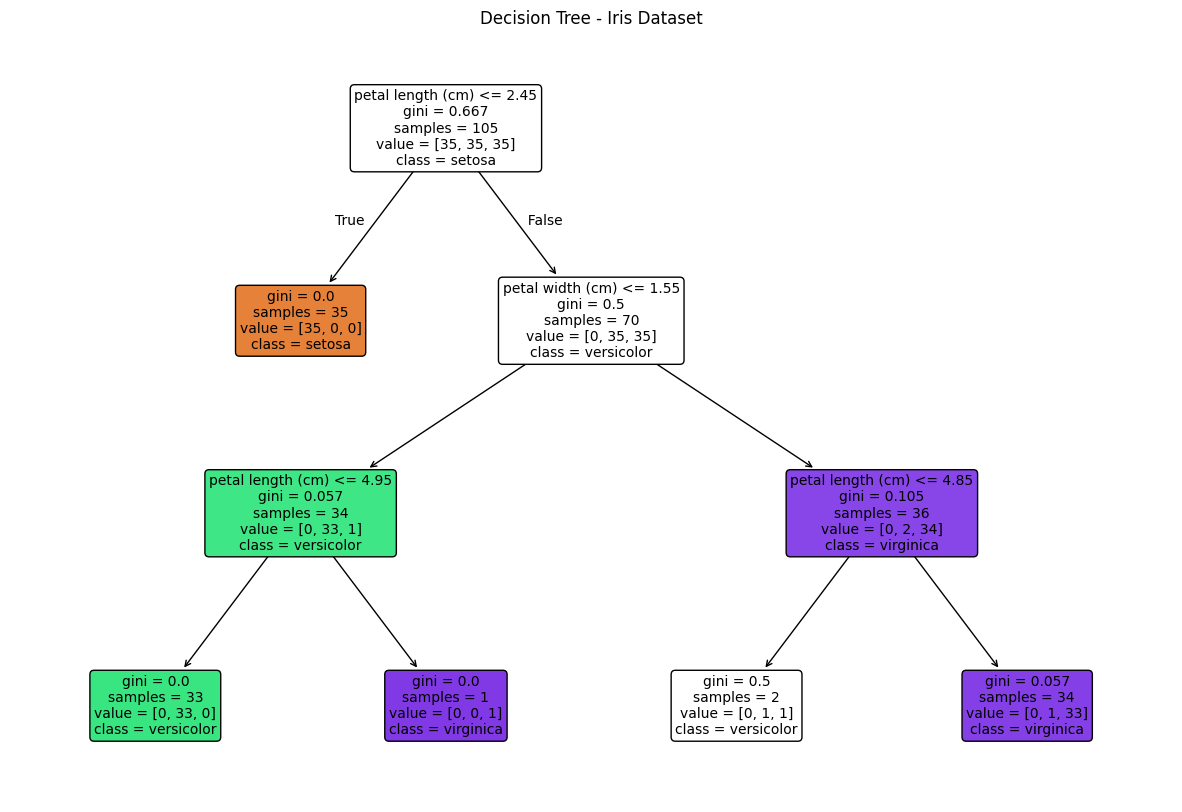

Feature Importance:
             feature  importance
2  petal length (cm)    0.563353
3   petal width (cm)    0.436647
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


In [ ]:
##VISUALISASI DECISION TREE
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualisasi pohon keputusan
plt.figure(figsize=(15, 10))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree - Iris Dataset")
plt.savefig("decision_tree.png", dpi=300, bbox_inches
="tight")
plt.show()
# Interpretasi: node menampilkan
# - samples: jumlah data di node
# - value: [jumlah kelas 0, kelas 1, kelas 2]
# - class: kelas mayoritas
# - gini/entropy: impurity

# Feature importance
importance = pd.DataFrame({
    "feature": iris.feature_names,
    "importance": dt.feature_importances_ }).sort_values("importance", ascending=False)
print("Feature Importance:")
print(importance)




In [ ]:
#IMPLEMENTASI RULE-BASED CLASSIFIER DARI SCRATCH
import pandas as pd
import numpy as np

class SimpleRuleBasedClassifier:
    def __init__(self):
        self.rules = []
        self.default_class = None

    def add_rule(self, conditions, class_label, confidence=None):
        # Tambah aturan IF-THEN conditions: dict {"feature": value}
        self.rules.append({
            "conditions": conditions,
            "class": class_label,
            "confidence": confidence or 1.0
        })

        # Urutkan berdasarkan confidence (descending)
        self.rules.sort(key=lambda x: x["confidence"], reverse=True)

    def predict_one(self, x):
        """Prediksi satu data point"""
        for rule in self.rules:
            match = True
            for feature, value in rule["conditions"].items():
                if x[feature] != value:
                    match = False
                    break
            if match:
                return rule["class"]
        return self.default_class

    def predict(self, X):
        return [self.predict_one(x) for x in X]

    def set_default(self, class_label):
        self.default_class = class_label


# Contoh penggunaan
data = [
    {"Outlook": "Sunny", "Temp": "Hot", "Play": "No"},
    {"Outlook": "Sunny", "Temp": "Mild", "Play": "No"},
    {"Outlook": "Overcast", "Temp": "Hot", "Play": "Yes"},
    {"Outlook": "Rainy", "Temp": "Mild", "Play": "Yes"},
    {"Outlook": "Rainy", "Temp": "Cool", "Play": "Yes"},
]

clf = SimpleRuleBasedClassifier()
clf.add_rule({"Outlook": "Overcast"}, "Yes", confidence=1.0)
clf.add_rule({"Outlook": "Sunny", "Temp": "Hot"}, "No", confidence=0.8)
clf.add_rule({"Outlook": "Rainy"}, "Yes", confidence=0.7)
clf.set_default("Yes")

# Testing
test_data = {"Outlook": "Sunny", "Temp": "Hot"}
print(f"Prediksi: {clf.predict_one(test_data)}")  # Output: No

Prediksi: No


In [ ]:
#EKSTRAKSI ATURAN DARI DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
import numpy as np

def extract_rules(tree, feature_names, class_names, node_id=0, current_rule=None):
    # Ekstrak aturan IF-THEN dari decision tree
    if current_rule is None:
        current_rule = []

    rules = []

    # Cek apakah node daun (leaf)
    if tree.children_left[node_id] == tree.children_right[node_id]:
        # Node daun: output kelas
        class_id = np.argmax(tree.value[node_id][0])
        rule_str = "IF " + " AND ".join(current_rule) + f" THEN {class_names[class_id]}"
        rules.append(rule_str)
    else:
        # Node internal: rekursif ke kiri dan kanan
        feature = feature_names[tree.feature[node_id]]
        threshold = tree.threshold[node_id]

        # Cabang kiri (<= threshold)
        left_rule = current_rule + [f"{feature} <= {threshold:.2f}"]
        rules.extend(
            extract_rules(
                tree,
                feature_names,
                class_names,
                tree.children_left[node_id],
                left_rule
            )
        )

        # Cabang kanan (> threshold)
        right_rule = current_rule + [f"{feature} > {threshold:.2f}"]
        rules.extend(
            extract_rules(
                tree,
                feature_names,
                class_names,
                tree.children_right[node_id],
                right_rule
            )
        )

    return rules


# Contoh ekstraksi dari model sebelumnya
iris = load_iris()
X = iris.data
y = iris.target

# Biar sesuai konteks kode lu (pakai train)
X_train, y_train = X, y

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X_train, y_train)

rules = extract_rules(dt.tree_, iris.feature_names, iris.target_names)

print("Aturan yang diekstrak:")
for i, rule in enumerate(rules):
    print(f"{i+1}. {rule}")

Aturan yang diekstrak:
1. IF petal length (cm) <= 2.45 THEN setosa
2. IF petal length (cm) > 2.45 AND petal width (cm) <= 1.75 THEN versicolor
3. IF petal length (cm) > 2.45 AND petal width (cm) > 1.75 THEN virginica


In [ ]:
#PERBANDINGAN DECISION TREE DENGAN RULE-BASED
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

# Load data (contoh: Titanic)
titanic = sns.load_dataset('titanic')
titanic = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived']]

titanic = titanic.dropna()
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

X = titanic.drop('survived', axis=1)
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = {
    'Decision Tree (Gini)': DecisionTreeClassifier(criterion='gini', max_depth=5),
    'Decision Tree (Entropy)': DecisionTreeClassifier(criterion='entropy', max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

                     Model  Accuracy  Precision  Recall      F1
0     Decision Tree (Gini)    0.7488     0.7011  0.6854  0.6932
1  Decision Tree (Entropy)    0.7488     0.7011  0.6854  0.6932
2            Random Forest    0.7953     0.7922  0.6854  0.7349
3               k-NN (k=5)    0.6744     0.6301  0.5169  0.5679
